In [1]:
from src.Models.modl import modl
from torch.utils.data import DataLoader
from src.Transforms import (pad, trim_coils, combine_coil, toTensor, permute, 
                        view_as_real, remove_slice_dim, fft_2d, normalize, addChannels)
from src.Dataset.undersampled_dataset import UndersampledKSpaceDataset
from torchvision.transforms import Compose
import numpy as np

import torch
from src.Utils import image_slices
from src.Models.varnet import VarNet

ModuleNotFoundError: No module named 'Models'

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def collate_fn(data):
    undersampled = [d['undersampled'] for d in data]
    sampled = [d['k_space'] for d in data]
    ismrmrd_header = [d['ismrmrd_header'] for d in data]
    mask = [d['mask'] for d in data]
    recon_rss = [d['reconstruction_rss'] for d in data]

    undersampled = torch.concat(undersampled, dim=0)
    sampled = torch.concat(sampled, dim=0)
    mask = torch.concat(mask, dim=0)

    data = {
        'undersampled': undersampled, 
        'sampled': sampled,
        'ismrmrd_header': ismrmrd_header,
        'mask': mask, 
        'recon': recon_rss,
    }
    return data

In [ ]:
transforms = Compose(
    (
        pad((640, 320)), 
        toTensor(),
        normalize(),
    )
)
dataset = UndersampledKSpaceDataset('/home/kadotab/projects/def-mchiew/kadotab/Datasets/fastMRI/multicoil_train', transforms=transforms, R=4)
dataloader = DataLoader(dataset, batch_size=1, collate_fn=collate_fn)
    

In [ ]:
data = next(iter(dataloader))

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = VarNet(2, 2, num_cascades=12, use_norm=True)
model.to(device)

VarNet(
  (cascade): ModuleList(
    (0): VarnetBlock(
      (unet): Unet(
        (down_sample_layers): ModuleList(
          (0): double_conv(
            (conv1): Conv2d(2, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (conv2): Conv2d(18, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (activation): LeakyReLU(negative_slope=0.2, inplace=True)
            (instance_norm1): InstanceNorm2d(18, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (instance_norm2): InstanceNorm2d(18, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (drop_out1): Dropout2d(p=0, inplace=False)
            (drop_out2): Dropout2d(p=0, inplace=False)
          )
          (1): Unet_down(
            (down): down(
              (max_pool): MaxPool2d(kernel_size=2, stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
            )
            (conv): double_conv(
              (conv1): Conv2d(1

In [ ]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from datetime import datetime

In [ ]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('/tmp/kadota_runs/' +  datetime.now().strftime("%Y%m%d-%H%M%S"))

In [ ]:
def train(model, loss_function, optimizer, dataloader, epoch=7):
    cur_loss = 0
    current_index = 0
    try:
        for e in range(epoch):
            for data in dataloader:

                sampled = data['sampled']
                mask = data['mask']
                undersampled = data['undersampled']
                for i in range(sampled.shape[0]):
                    optimizer.zero_grad()
                    sampled_slice = sampled[[i],...]
                    mask_slice = mask[[i],...]
                    undersampled_slice = undersampled[[i],...]
                    mask_slice = mask_slice.to(device)
                    mask_slice = mask_slice.bool()
                    undersampled_slice = undersampled_slice.to(device)
                    sampled_slice = sampled_slice.to(device)

                    predicted_sampled = model(undersampled_slice, mask_slice)
                    loss = loss_function(torch.view_as_real(predicted_sampled), torch.view_as_real(sampled_slice))

                    loss.backward()
                    optimizer.step()
                    cur_loss += loss.item()
                    current_index += 1
                    if current_index % 100 == 99:
                        writer.add_histogram('sens/weights1', next(model.sens_model.model.conv1d.parameters()), current_index)
                        writer.add_histogram('castcade0/weights1', next(model.cascade[0].unet.conv1d.parameters()), current_index)
                        writer.add_histogram('castcade0/weights2', next(model.cascade[1].unet.conv1d.parameters()), current_index)
                        writer.add_histogram('castcade0/weights11', next(model.cascade[-2].unet.conv1d.parameters()), current_index)
                        writer.add_histogram('castcade0/weights12', next(model.cascade[-1].unet.conv1d.parameters()), current_index)
                        writer.add_histogram('varnet/regularizer', model.lambda_reg.data, current_index)
                        writer.add_scalar('Loss/train', cur_loss, current_index)
                        print(f"Iteration: {current_index + 1:>d}, Loss: {cur_loss:>7f}")
                        cur_loss = 0
    except KeyboardInterrupt:
        pass

    model_name = model.__class__.__name__
    date = datetime.now().strftime("%Y%m%d-%H%M%S")
    torch.save({
        model: model.state_dict(), 
        optimizer: optimizer.state_dict()
        }, './Model_Weights/' + date + model_name + '.pt')

In [ ]:
train(model, loss_fn, optimizer, dataloader)

In [ ]:
image = model(data['undersampled'][[5], :, :, :].to(device), data['mask'][[5], :, :].bool().to(device))

In [ ]:
sense = model.sens_model(data['undersampled'][[5], :, :, :].to(device))

(<Figure size 720x720 with 20 Axes>,
 array([[<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >,
         <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >,
         <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >,
         <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >,
         <AxesSubplot: >],
        [<AxesSubplot: >, <AxesSubplot: >, <AxesSubplot: >,
         <AxesSubplot: >]], dtype=object))

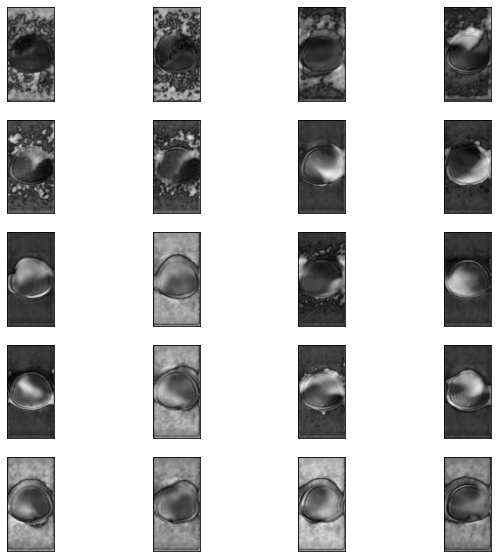

In [ ]:
image_slices(sense[0, :, :, :].cpu().detach(), cmap='gray')

In [ ]:
from Utils import ifft_2d_img

In [ ]:
y= torch.sqrt(ifft_2d_img(image, axes=[-1, -2]).pow(2).sum(1))

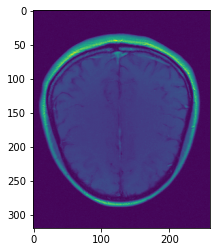

In [ ]:
plt.imshow(data['recon'][0][5,:, :])


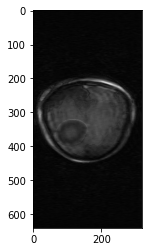

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(np.squeeze(np.abs(y.cpu().detach().numpy())), cmap='gray')